# Felius Walking-Activity Validation

This notebook tests the main unresolved preprocessing question: whether Felius full-trial recordings contain identifiable walking-only regions. The previous notebook used the whole Felius trial provisionally because no gait-event annotations were found in the local release.

The analysis scans 10-second windows, measures foot movement and gait-like periodicity, compares full-trial failures with recoverable local windows, and writes an audit table. It does not train a model or materialize the final training tensor.

## Decision being tested

A Felius window is marked as a conservative walking candidate when both feet show enough movement and at least one foot shows physiologically plausible periodicity. The thresholds are deliberately treated as an audit sensitivity analysis, not as ground truth.

The output will tell us whether we can segment Felius with a reproducible signal-based rule, whether manual review is needed, or whether Felius should remain a secondary dataset for the first classifier.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import correlate

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from features.signal_utils import dominant_stride_frequency

MANIFEST_PATH = PROJECT_ROOT / 'data' / 'interim' / 'ml_readiness_manifest.csv'
manifest = pd.read_csv(MANIFEST_PATH)
felius = manifest[manifest['dataset_id'] == 'felius_2024'].copy().reset_index(drop=True)
felius['participant_key'] = felius['dataset_id'] + ':' + felius['subject'].astype(str)

FS_HZ = 100.0
WINDOW_SAMPLES = 1000
HOP_SAMPLES = 500
MIN_STRIDE_LAG = int(0.4 * FS_HZ)
MAX_STRIDE_LAG = int(2.0 * FS_HZ)

print('Felius trials:', len(felius))
print('Felius participants:', felius['participant_key'].nunique())


Felius trials: 377
Felius participants: 166


In [2]:
def load_felius_signal(row):
    paths = {}
    for raw_path in str(row['raw_files']).split('|'):
        sensor = Path(raw_path).name.rsplit('_', 1)[-1].replace('.csv', '')
        paths[sensor] = PROJECT_ROOT / raw_path

    frames = []
    for sensor in ['lowback', 'leftfoot', 'rightfoot']:
        frame = pd.read_csv(paths[sensor])
        frame = frame[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].astype(float)
        frames.append(frame.to_numpy())

    n_samples = min(len(frame) for frame in frames)
    return np.concatenate([frame[:n_samples] for frame in frames], axis=1)


def accel_magnitude(signal, placement_start):
    accel = signal[:, placement_start:placement_start + 3]
    return np.linalg.norm(accel, axis=1)


def periodicity_strength(signal_1d):
    x = np.asarray(signal_1d, dtype=float)
    if len(x) < 2 * MAX_STRIDE_LAG or not np.isfinite(x).all():
        return np.nan, np.nan
    x = x - np.mean(x)
    if np.std(x) == 0:
        return np.nan, np.nan
    ac = correlate(x, x, mode='full', method='fft')[len(x) - 1:]
    if ac[0] <= 0:
        return np.nan, np.nan
    ac = ac / ac[0]
    search = ac[MIN_STRIDE_LAG:MAX_STRIDE_LAG]
    peak_offset = int(np.argmax(search))
    peak_lag = MIN_STRIDE_LAG + peak_offset
    peak = float(search[peak_offset])
    at_boundary = peak_offset <= 1 or peak_offset >= len(search) - 2
    if at_boundary:
        return peak, np.nan
    return peak, FS_HZ / peak_lag


def full_trial_periodicity(signal):
    left = accel_magnitude(signal, 6)
    right = accel_magnitude(signal, 12)
    freqs = [dominant_stride_frequency(left, FS_HZ), dominant_stride_frequency(right, FS_HZ)]
    return float(np.nanmedian(freqs)) if np.isfinite(freqs).any() else np.nan


def scan_windows(signal, row):
    left = accel_magnitude(signal, 6)
    right = accel_magnitude(signal, 12)
    lowback = accel_magnitude(signal, 0)
    records = []
    for start in range(0, len(signal) - WINDOW_SAMPLES + 1, HOP_SAMPLES):
        end = start + WINDOW_SAMPLES
        left_activity = float(np.std(left[start:end]))
        right_activity = float(np.std(right[start:end]))
        left_peak, left_freq = periodicity_strength(left[start:end])
        right_peak, right_freq = periodicity_strength(right[start:end])
        records.append({
            'dataset_id': row['dataset_id'],
            'participant_key': row['participant_key'],
            'trial_id': row['trial_id'],
            'label': row['label'],
            'start_sample': start,
            'end_sample': end,
            'duration_s': len(signal) / FS_HZ,
            'left_foot_activity_g': left_activity,
            'right_foot_activity_g': right_activity,
            'foot_activity_g': float(np.nanmean([left_activity, right_activity])),
            'left_periodicity': left_peak,
            'right_periodicity': right_peak,
            'foot_periodicity': float(np.nanmax([left_peak, right_peak])),
            'left_stride_frequency_hz': left_freq,
            'right_stride_frequency_hz': right_freq,
            'lowback_activity_g': float(np.std(lowback[start:end])),
        })
    return pd.DataFrame(records)


## Scan every Felius trial

This is an audit pass only. The signal is not saved as a training tensor yet. Each row below represents one 10-second window with a 5-second hop.

In [3]:
window_records = []
trial_records = []
for _, row in felius.iterrows():
    signal = load_felius_signal(row)
    trial_records.append({
        'dataset_id': row['dataset_id'],
        'participant_key': row['participant_key'],
        'trial_id': row['trial_id'],
        'label': row['label'],
        'n_samples': len(signal),
        'duration_s': len(signal) / FS_HZ,
        'full_trial_stride_frequency_hz': full_trial_periodicity(signal),
    })
    window_records.append(scan_windows(signal, row))

windows = pd.concat(window_records, ignore_index=True)
trials = pd.DataFrame(trial_records)
print('Scanned trials:', len(trials))
print('Scanned windows:', len(windows))
print('Trial duration summary (s):')
print(trials['duration_s'].describe().round(2))


Scanned trials: 377
Scanned windows: 9740
Trial duration summary (s):
count    377.00
mean     136.65
std       15.35
min        0.00
25%      133.11
50%      135.89
75%      139.93
max      202.70
Name: duration_s, dtype: float64


In [4]:
threshold_grid = []
for activity_threshold in [0.01, 0.02, 0.04]:
    for periodicity_threshold in [0.20, 0.25, 0.35]:
        candidate = (
            (windows['left_foot_activity_g'] >= activity_threshold)
            & (windows['right_foot_activity_g'] >= activity_threshold)
            & (windows['foot_periodicity'] >= periodicity_threshold)
        )
        per_trial = windows.assign(candidate=candidate).groupby('trial_id')['candidate'].sum()
        threshold_grid.append({
            'activity_threshold_g': activity_threshold,
            'periodicity_threshold': periodicity_threshold,
            'candidate_windows': int(candidate.sum()),
            'trials_with_candidate_windows': int((per_trial > 0).sum()),
            'trials_with_3plus_candidate_windows': int((per_trial >= 3).sum()),
            'participants_with_candidate_windows': int(windows.loc[candidate, 'participant_key'].nunique()),
        })

threshold_audit = pd.DataFrame(threshold_grid)
threshold_audit


,activity_threshold_g,periodicity_threshold,candidate_windows,trials_with_candidate_windows,trials_with_3plus_candidate_windows,participants_with_candidate_windows
0,0.01,0.20,8479,368,365,163
1,0.01,0.25,8162,360,352,160
2,0.01,0.35,7471,348,340,155
3,0.02,0.20,8467,368,364,163
4,0.02,0.25,8155,360,351,160
5,0.02,0.35,7471,348,340,155
6,0.04,0.20,8442,367,363,163
7,0.04,0.25,8136,358,351,159
8,0.04,0.35,7463,348,340,155


In [5]:
ACTIVITY_THRESHOLD_G = 0.02
PERIODICITY_THRESHOLD = 0.25
windows['walking_candidate'] = (
    (windows['left_foot_activity_g'] >= ACTIVITY_THRESHOLD_G)
    & (windows['right_foot_activity_g'] >= ACTIVITY_THRESHOLD_G)
    & (windows['foot_periodicity'] >= PERIODICITY_THRESHOLD)
)
candidate_counts = windows.groupby(['trial_id', 'participant_key', 'label']).agg(
    total_windows=('walking_candidate', 'size'),
    candidate_windows=('walking_candidate', 'sum'),
    median_activity_g=('foot_activity_g', 'median'),
    median_periodicity=('foot_periodicity', 'median'),
).reset_index()
candidate_counts['candidate_fraction'] = candidate_counts['candidate_windows'] / candidate_counts['total_windows']
candidate_counts['full_trial_failed_periodicity'] = candidate_counts['trial_id'].map(
    trials.set_index('trial_id')['full_trial_stride_frequency_hz'].isna()
)

print('Candidate-window summary by label:')
print(candidate_counts.groupby('label')[['total_windows', 'candidate_windows']].sum())
print()
print('Trials with at least one candidate window:')
print(candidate_counts.groupby('label')['candidate_windows'].apply(lambda s: (s > 0).sum()))
print()
print('Full-trial periodicity failures recovered by local candidates:')
failed = candidate_counts['full_trial_failed_periodicity']
print(candidate_counts.loc[failed].groupby('label')['candidate_windows'].agg(['count', 'sum', 'mean']))


Candidate-window summary by label:
         total_windows  candidate_windows
label                                    
healthy           1438               1435
stroke            8302               6720

Trials with at least one candidate window:
label
healthy     59
stroke     301
Name: candidate_windows, dtype: int64

Full-trial periodicity failures recovered by local candidates:
        count  sum      mean
label                       
stroke     57  446  7.824561


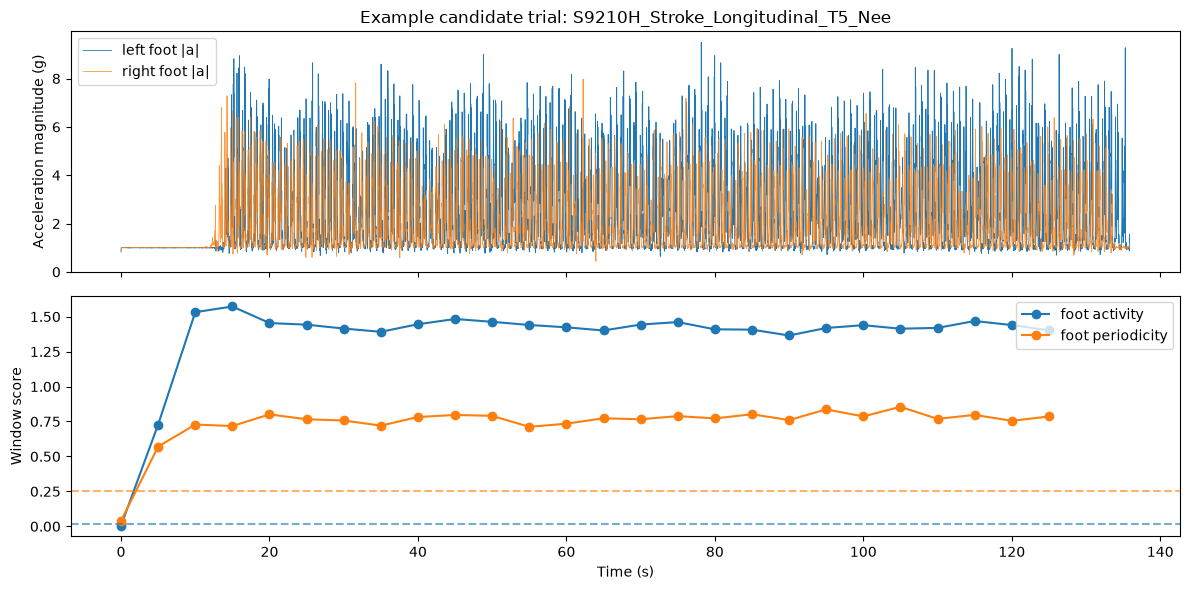

In [6]:
best_window = windows.sort_values(['foot_periodicity', 'foot_activity_g'], ascending=False).iloc[0]
review_trial = best_window['trial_id']
review_row = felius[felius['trial_id'] == review_trial].iloc[0]
review_signal = load_felius_signal(review_row)
review_left = accel_magnitude(review_signal, 6)
review_right = accel_magnitude(review_signal, 12)
review_t = np.arange(len(review_signal)) / FS_HZ

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(review_t, review_left, linewidth=0.6, label='left foot |a|')
axes[0].plot(review_t, review_right, linewidth=0.6, label='right foot |a|', alpha=0.8)
axes[0].set_ylabel('Acceleration magnitude (g)')
axes[0].set_title(f'Example candidate trial: {review_trial}')
axes[0].legend()

trial_windows = windows[windows['trial_id'] == review_trial]
axes[1].plot(trial_windows['start_sample'] / FS_HZ, trial_windows['foot_activity_g'], marker='o', label='foot activity')
axes[1].plot(trial_windows['start_sample'] / FS_HZ, trial_windows['foot_periodicity'], marker='o', label='foot periodicity')
axes[1].axhline(ACTIVITY_THRESHOLD_G, linestyle='--', color='tab:blue', alpha=0.6)
axes[1].axhline(PERIODICITY_THRESHOLD, linestyle='--', color='tab:orange', alpha=0.6)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Window score')
axes[1].legend()
fig.tight_layout()
plt.show()


In [7]:
interim = PROJECT_ROOT / 'data' / 'interim'
windows_path = interim / 'felius_walking_window_audit.csv'
trial_path = interim / 'felius_walking_validation_summary.csv'
threshold_path = interim / 'felius_walking_threshold_sensitivity.csv'
signal_path = interim / 'felius_trial_signal_audit.csv'
windows.to_csv(windows_path, index=False)
candidate_counts.to_csv(trial_path, index=False)
threshold_audit.to_csv(threshold_path, index=False)
trials.to_csv(signal_path, index=False)
print('Wrote:')
print(windows_path)
print(trial_path)
print(threshold_path)
print(signal_path)
print('Trials shorter than one 10-second window:', int((trials['n_samples'] < WINDOW_SAMPLES).sum()))
print(trials.loc[trials['n_samples'] < WINDOW_SAMPLES, ['trial_id', 'participant_key', 'label', 'n_samples', 'duration_s']].to_string(index=False))


Wrote:
C:\Users\frank\Documents\MR-ICT Review Paper\data\interim\felius_walking_window_audit.csv
C:\Users\frank\Documents\MR-ICT Review Paper\data\interim\felius_walking_validation_summary.csv
C:\Users\frank\Documents\MR-ICT Review Paper\data\interim\felius_walking_threshold_sensitivity.csv
C:\Users\frank\Documents\MR-ICT Review Paper\data\interim\felius_trial_signal_audit.csv
Trials shorter than one 10-second window: 2
                         trial_id    participant_key  label  n_samples  duration_s
 S8099Z_Stroke_Longitudinal_T2_Ja felius_2024:S8099Z stroke          0         0.0
S9848Z_Stroke_Longitudinal_T2_Nee felius_2024:S9848Z stroke          0         0.0


## Gate before window materialization

Proceed to the next notebook only if the audit shows a stable number of candidate windows across reasonable thresholds and candidate windows are not concentrated in only one cohort or a few participants. If the result is unstable, manually inspect representative trials and keep Felius out of the first end-to-end classifier until segmentation is defensible.

The next implementation notebook, after this review, can materialize normalized windows using the accepted candidate rule and the participant-level split files.